<a href="https://colab.research.google.com/github/dbthyy/med-audio-synthetic-augmentation/blob/main/01_Data_Preprocessing/Preprocessing_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Synthetic Data Augmentation for Medical Audio Classification
**Reproduction + Extension of McShannon et al. (2025)**

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
# Kiểm tra GPU
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


---
## 1. Data Preprocessing

- Load Coswara dataset (cough recordings)
- Filter: healthy (label=0) vs COVID+ (label=1)
- Mel-spectrogram: 128 mels, 0–8000 Hz, FFT=2048, hop=512
- **GroupShuffleSplit** theo user_id (tránh data leakage)
- Z-score normalization trên tập train
- Output: `dataset.pt`

In [ ]:
!git clone https://github.com/iiscleap/Coswara-Data.git

Cloning into 'Coswara-Data'...
remote: Enumerating objects: 995, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 995 (delta 58), reused 45 (delta 45), pack-reused 928 (from 3)
Receiving objects: 100% (995/995), 15.97 GiB | 44.21 MiB/s, done.
Resolving deltas: 100% (422/422), done.
Updating files: 100% (336/336), done.


In [ ]:
!python 01_data_preprocessing.py

[Data] Total samples after filter: 4317
covid_status
healthy              2955
positive_mild         852
positive_moderate     330
positive_asymp        180
Name: count, dtype: int64
[Data] Removed 149 silent files.
[Split] Train: {np.int64(0): np.int64(2010), np.int64(1): np.int64(906)}
[Split] Val: {np.int64(0): np.int64(432), np.int64(1): np.int64(196)}
[Split] Test: {np.int64(0): np.int64(394), np.int64(1): np.int64(230)}
[Mel] Train (2916, 128, 94, 1) | Val (628, 128, 94, 1) | Test (624, 128, 94, 1)
[Save] Dataset saved → dataset.pt

[Done] Preprocessing completed in 15.3 min


## EDA

=== Dataset Summary ===
  Train: 2916 samples | Healthy=2010 (68.9%) | COVID+=906 (31.1%)
  Val  :  628 samples | Healthy=432 (68.8%) | COVID+=196 (31.2%)
  Test :  624 samples | Healthy=394 (63.1%) | COVID+=230 (36.9%)


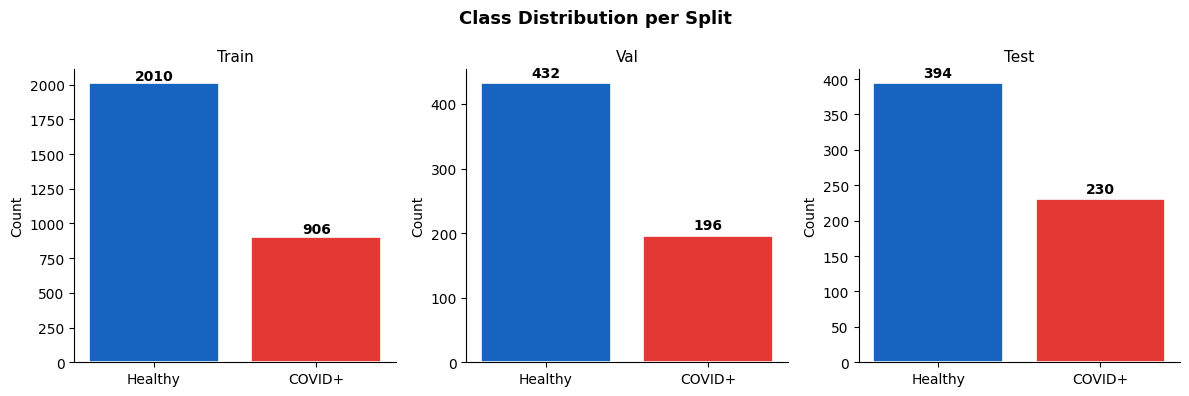

In [ ]:
# Kiểm tra và visualize dataset
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

data = torch.load('dataset.pt', map_location='cpu', weights_only=False)

y_train = data['y_train'].numpy()
y_val   = data['y_val'].numpy()
y_test  = data['y_test'].numpy()

print('=== Dataset Summary ===')
for split, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    n_healthy = (y == 0).sum()
    n_covid   = (y == 1).sum()
    print(f'  {split:5s}: {len(y):4d} samples | '
          f'Healthy={n_healthy} ({n_healthy/len(y)*100:.1f}%) | '
          f'COVID+={n_covid} ({n_covid/len(y)*100:.1f}%)')

# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Class Distribution per Split', fontsize=13, fontweight='bold')
for ax, (split, y) in zip(axes, [('Train', y_train), ('Val', y_val), ('Test', y_test)]):
    counts = [( y==0).sum(), (y==1).sum()]
    bars = ax.bar(['Healthy', 'COVID+'], counts,
                  color=['#1565C0', '#E53935'], edgecolor='white', linewidth=1.2)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(c), ha='center', va='bottom', fontweight='bold')
    ax.set_title(split, fontsize=11)
    ax.set_ylabel('Count')
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('plot_00_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
import IPython.display as ipd
X = data['X_train']
ipd.Audio(X[0], rate=16000)

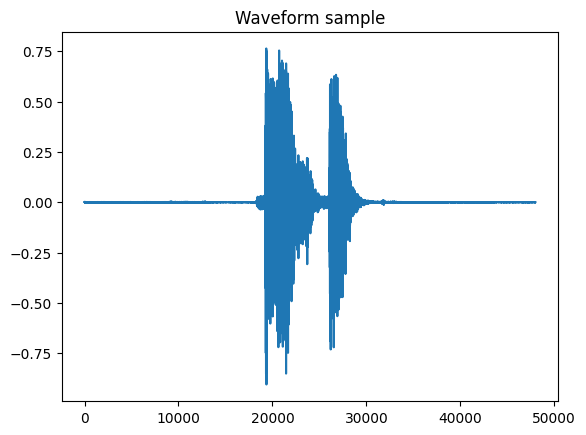

In [ ]:
plt.plot(X[0])
plt.title("Waveform sample")
plt.show()

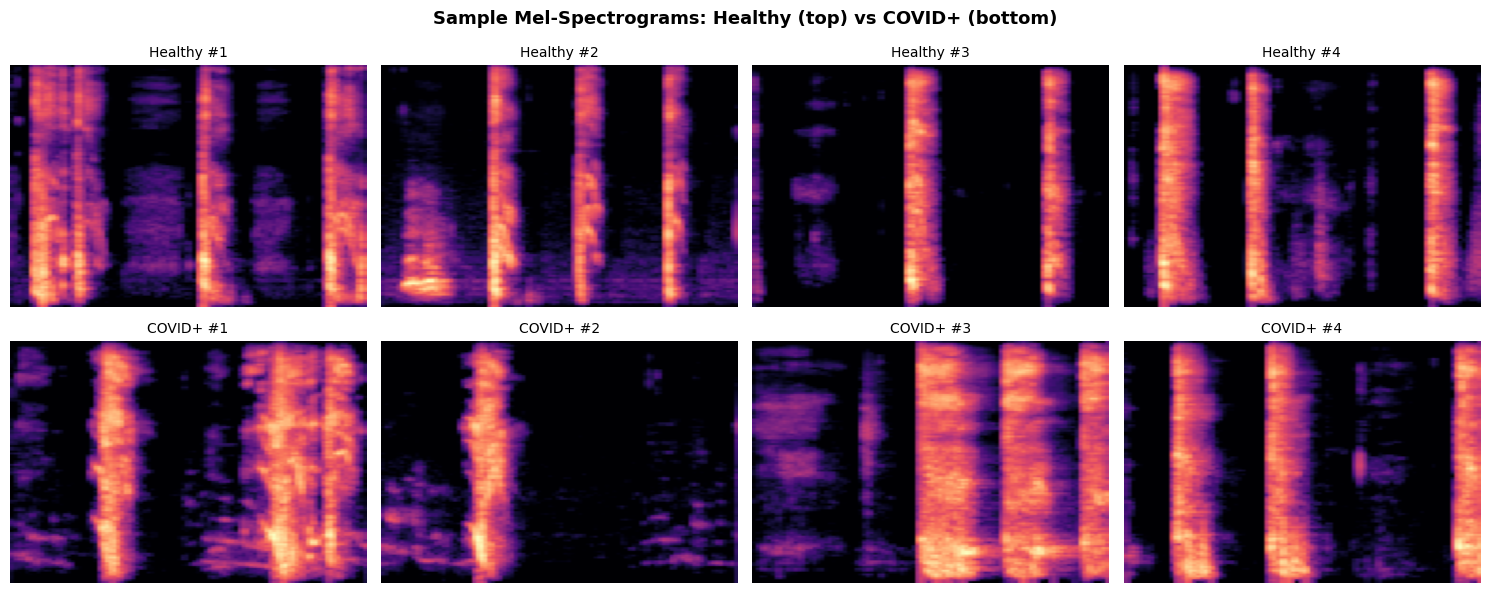

Spectrogram shape: torch.Size([128, 94, 1]) (H × W × 1)


In [ ]:
# Visualize sample mel-spectrograms (Healthy vs COVID+)
X_train = data['X_train']

healthy_idx = (y_train == 0).nonzero()[0]
covid_idx   = (y_train == 1).nonzero()[0]

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
fig.suptitle('Sample Mel-Spectrograms: Healthy (top) vs COVID+ (bottom)',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes[0]):
    spec = X_train[healthy_idx[i]].squeeze().numpy()
    im = ax.imshow(spec, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'Healthy #{i+1}', fontsize=10)
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    spec = X_train[covid_idx[i]].squeeze().numpy()
    ax.imshow(spec, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'COVID+ #{i+1}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('plot_01_sample_spectrograms.png', dpi=120, bbox_inches='tight')
plt.show()
print('Spectrogram shape:', X_train[0].shape, '(H × W × 1)')